Lap 02: 2.1.3_Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic
Nguyễn Thị Thu Thảo

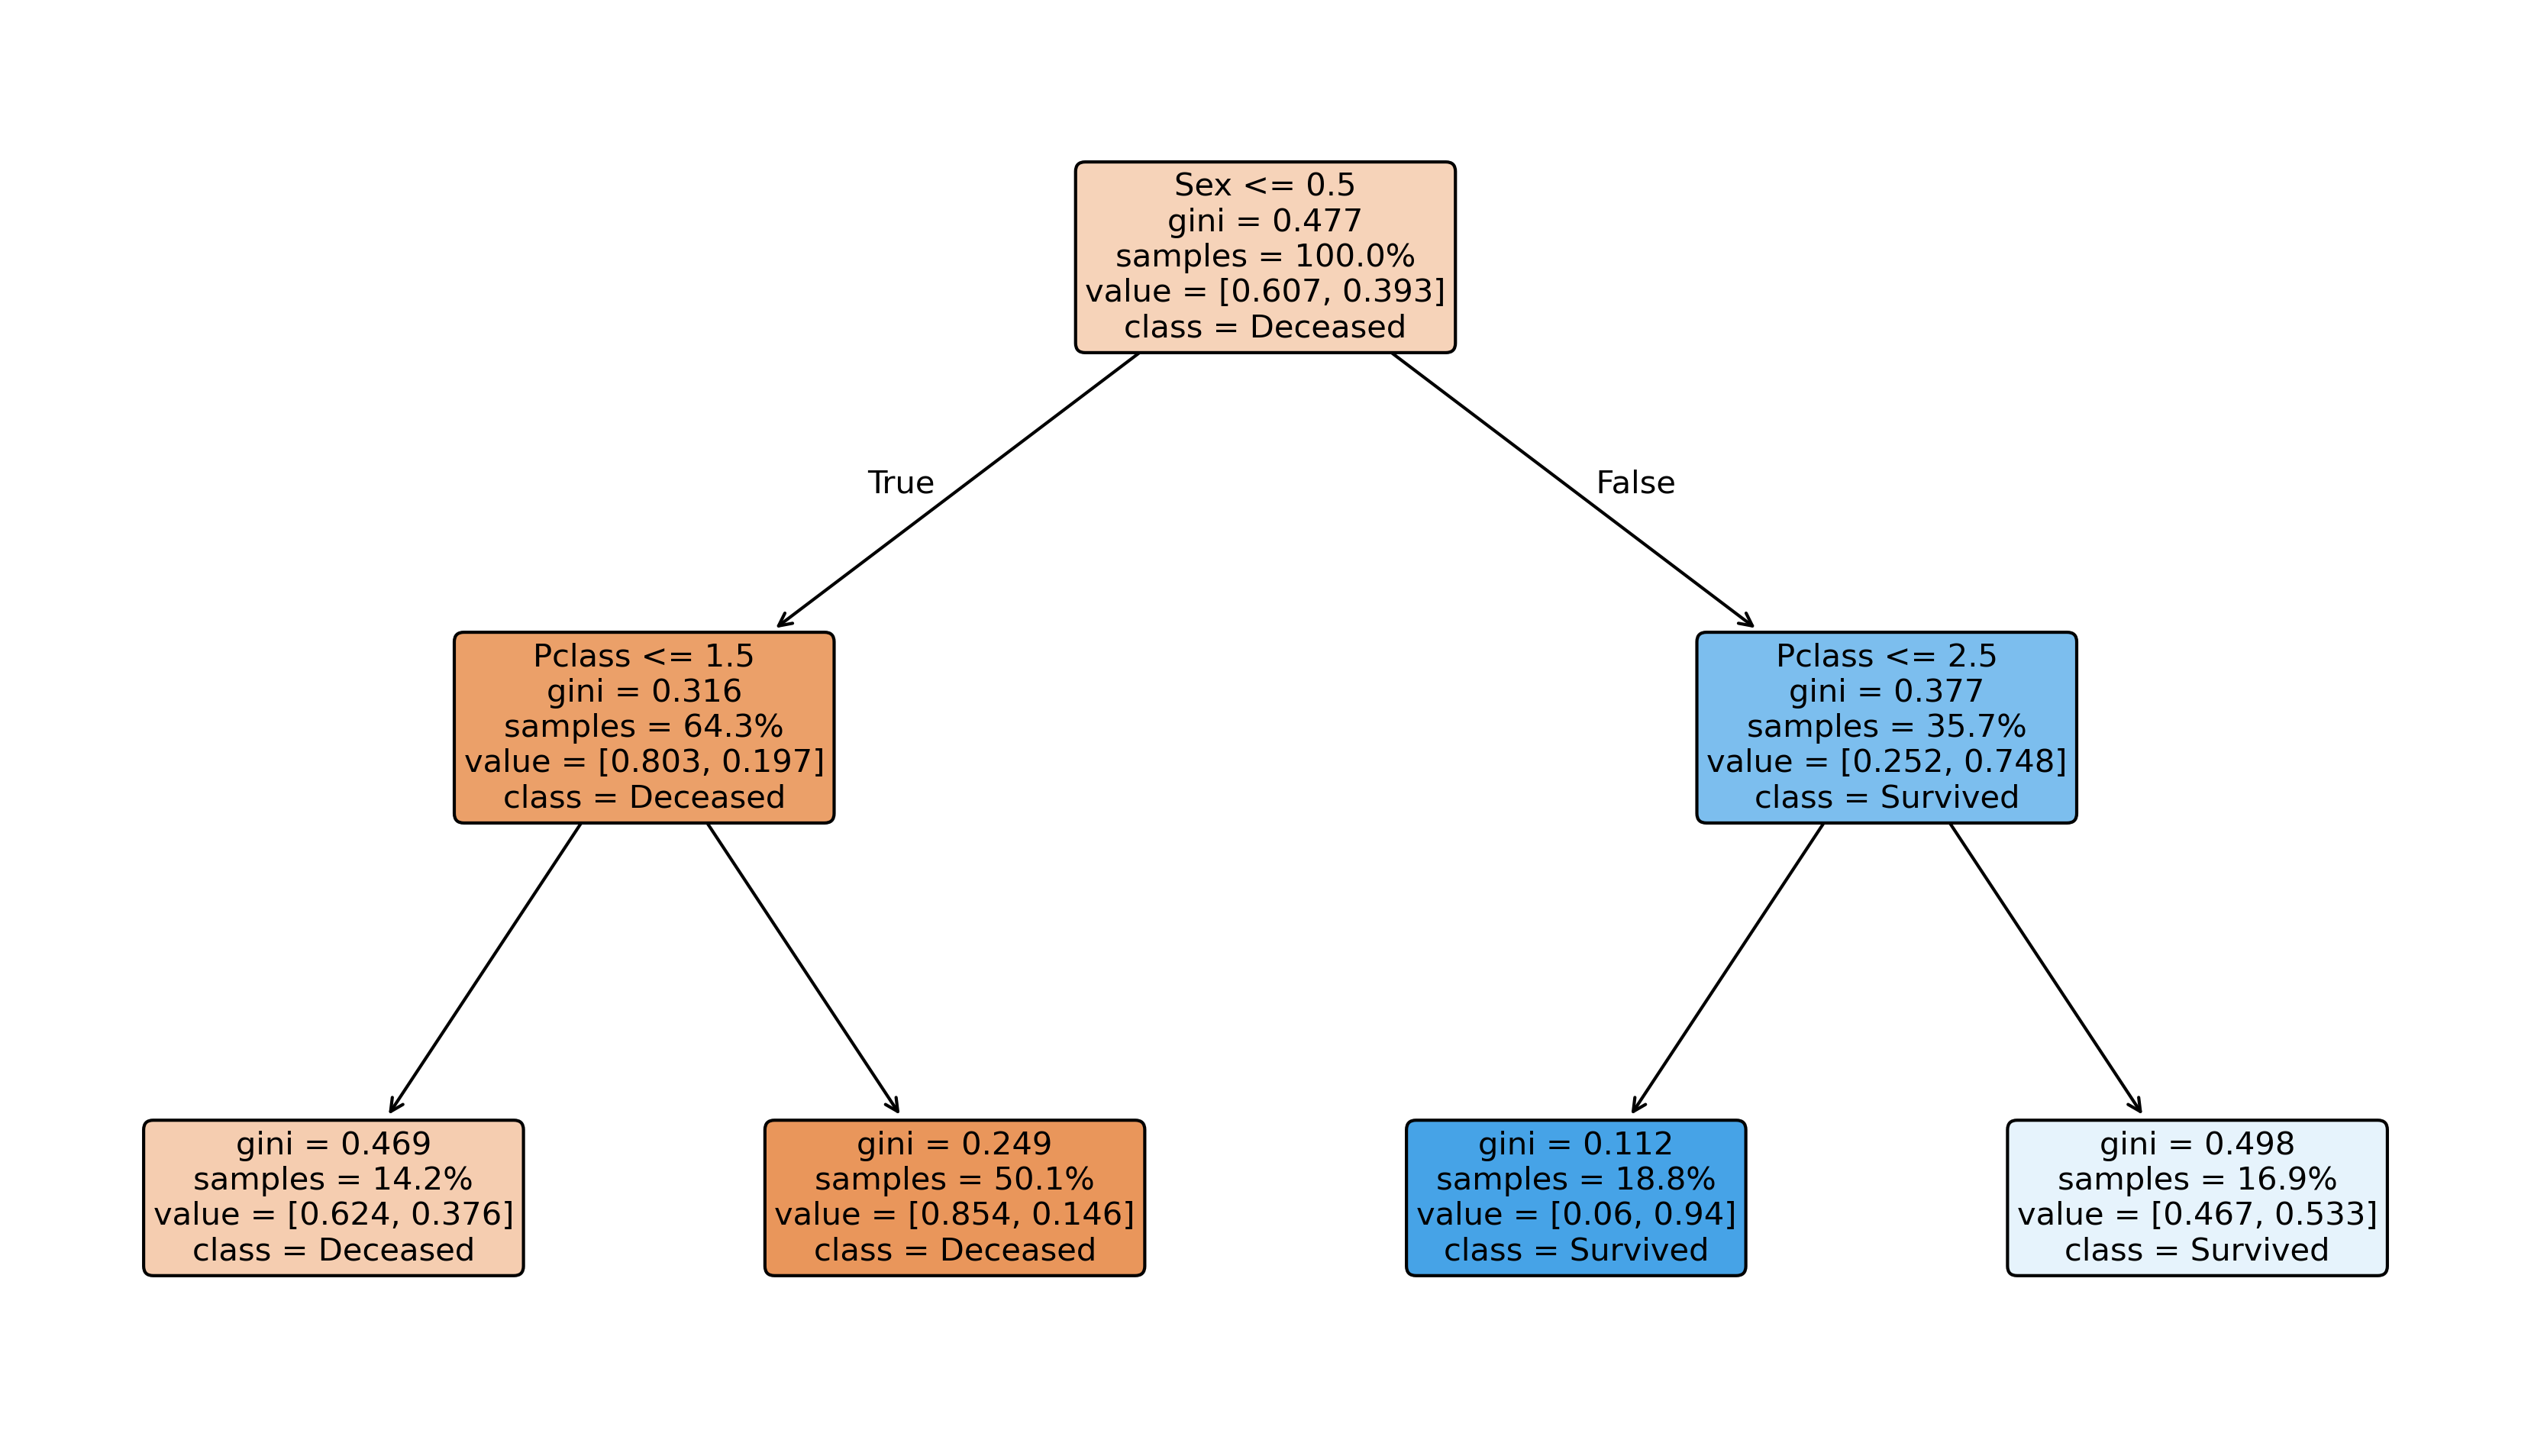

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree

# --- BƯỚC 1: Đọc dữ liệu Titanic trực tuyến ---
url_train = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url_train)

# --- BƯỚC 2: Tiền xử lý dữ liệu (Chuyển chữ thành số & Điền giá trị khuyết) ---
# Điền tuổi bị thiếu bằng giá trị trung vị
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
# Điền cảng bị thiếu bằng cảng xuất hiện nhiều nhất
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')

# Chuyển cột 'Sex' (female/male) thành (1/0)
titanic_df['Sex'] = titanic_df['Sex'].map({'female': 1, 'male': 0})

# Chuyển cột 'Embarked' (C, Q, S) thành số bằng One-Hot Encoding
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True)

# --- BƯỚC 3: Lọc bỏ các cột không liên quan và chọn đặc trưng (Features) ---
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

X = titanic_df[features].values
y = titanic_df['Survived'].values

# --- BƯỚC 4: Chia tập dữ liệu Train / Test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=24
)

# --- BƯỚC 5: Khởi tạo và huấn luyện Cây quyết định với độ sâu tối đa là 2 ---
dt = tree.DecisionTreeClassifier(max_depth=2, criterion='gini') 
dt.fit(X_train, y_train)

# --- BƯỚC 6: Trực quan hóa cây quyết định (Thay thế cho gói graphviz bị lỗi) ---
# Thiết lập kích thước khung tranh (độ phân giải cao 300 DPI để nhìn rõ chữ)
plt.figure(figsize=(14, 8), dpi=300)

# Vẽ cây quyết định tương đương với cấu hình graphviz của bạn
tree.plot_tree(
    dt, 
    feature_names=features, 
    class_names=['Deceased', 'Survived'], 
    filled=True, 
    rounded=True,
    proportion=True,      # Hiển thị tỷ lệ phần trăm phân bổ mẫu
    fontsize=10           # Kích thước chữ trong các ô
)

# Hiển thị biểu đồ cây trực tiếp dưới ô code
plt.show()

Fitting 4 folds for each of 7 candidates, totalling 28 fits

 ĐỘ SÂU (max_depth) TỐT NHẤT CHO TITANIC: 4
 Điểm ROC AUC tốt nhất trên tập kiểm định: 0.8400


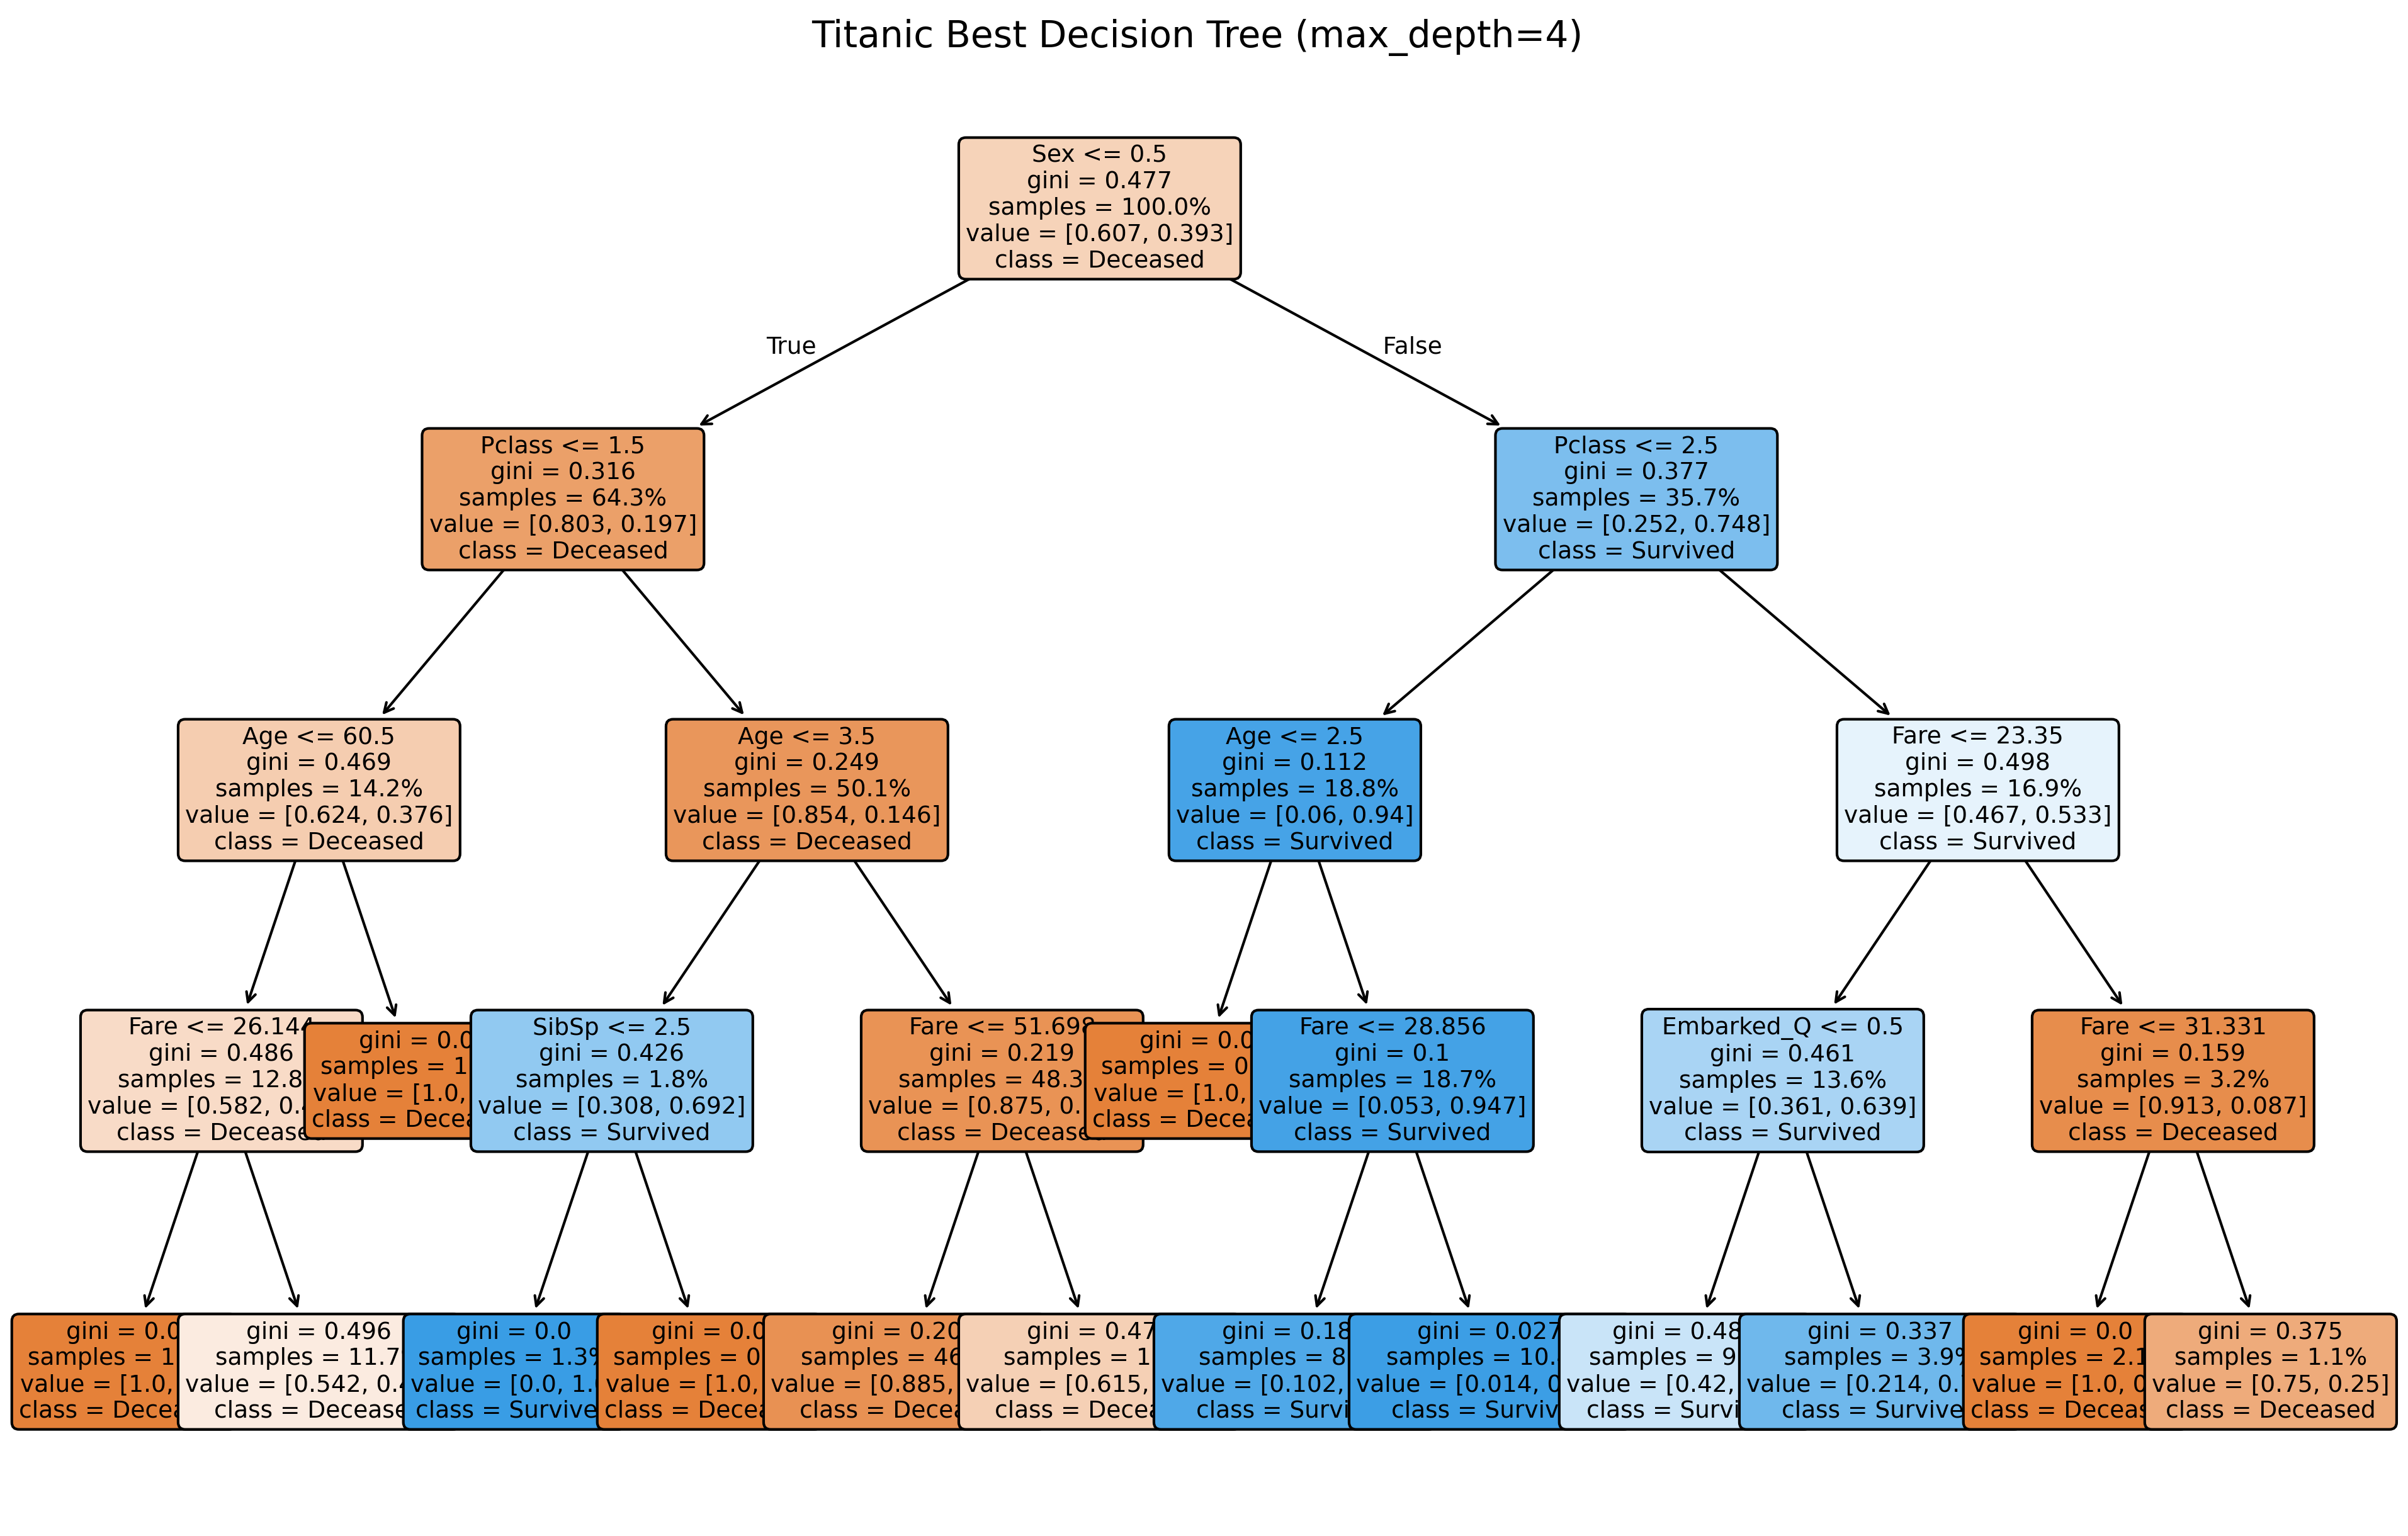

In [7]:
import numpy as np  # Khai báo để tránh lỗi np.nan
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. Định nghĩa lưới tham số muốn thử nghiệm
params = {'max_depth': [1, 2, 4, 6, 8, 10, 12]}

# 2. Khởi tạo mô hình nền tảng
dt = tree.DecisionTreeClassifier(criterion='gini', random_state=24)

# 3. Cấu hình bộ tìm kiếm GridSearchCV
cv = GridSearchCV(
    estimator=dt, 
    param_grid=params, 
    scoring='roc_auc', 
    cv=4, 
    verbose=1, 
    n_jobs=-1,              # Dùng -1 để tận dụng toàn bộ CPU của máy, giúp chạy nhanh hơn
    refit=True, 
    error_score=np.nan, 
    return_train_score=True
)

# 4. Tiến hành quét dữ liệu Titanic để tìm siêu tham số tối ưu
cv.fit(X_train, y_train)

# --- PHẦN VIẾT TIẾP: XUẤT KẾT QUẢ VÀ TRỰC QUAN HÓA ---

# In ra độ sâu tốt nhất tìm được
print(f"\n ĐỘ SÂU (max_depth) TỐT NHẤT CHO TITANIC: {cv.best_params_['max_depth']}")
print(f" Điểm ROC AUC tốt nhất trên tập kiểm định: {cv.best_score_:.4f}")

# Lấy ra mô hình tốt nhất đã được tự động huấn luyện lại (refit)
best_dt = cv.best_estimator_

# Vẽ cây quyết định tối ưu nhất vừa tìm được
plt.figure(figsize=(16, 10), dpi=300)
tree.plot_tree(
    best_dt, 
    feature_names=features, 
    class_names=['Deceased', 'Survived'], 
    filled=True, 
    rounded=True,
    proportion=True,
    fontsize=9
)
plt.title(f"Titanic Best Decision Tree (max_depth={cv.best_params_['max_depth']})", fontsize=14)
plt.show()

Yếu tố quyết định hàng đầu (Root Node): Cột thuộc tính đầu tiên được dùng để rẽ nhánh ngay ở đỉnh cây chính là Sex <= 0.5 (Giới tính). Điều này chứng tỏ mô hình nhận định giới tính là yếu tố then chốt nhất.

Nhánh bên trái (True - Nam) phần lớn dẫn tới kết quả màu cam (Deceased - Tử vong).

Nhánh bên phải (False - Nữ) phần lớn dẫn tới các nút màu xanh dương (Survived - Sống sót). Quy luật này hoàn toàn khớp với thực tế lịch sử (ưu tiên phụ nữ và trẻ em).

Các tầng rẽ nhánh tiếp theo: Đối với nhóm nam giới, mô hình xét tiếp đến Hạng vé (Pclass <= 1.5) và Tuổi (Age). Đối với nhóm nữ giới, mô hình xét tiếp đến Hạng vé và Giá vé (Fare). Điều này cho thấy sự phân hóa giàu nghèo (hạng vé cao) ảnh hưởng trực tiếp đến cơ hội thoát thân của hành khách.

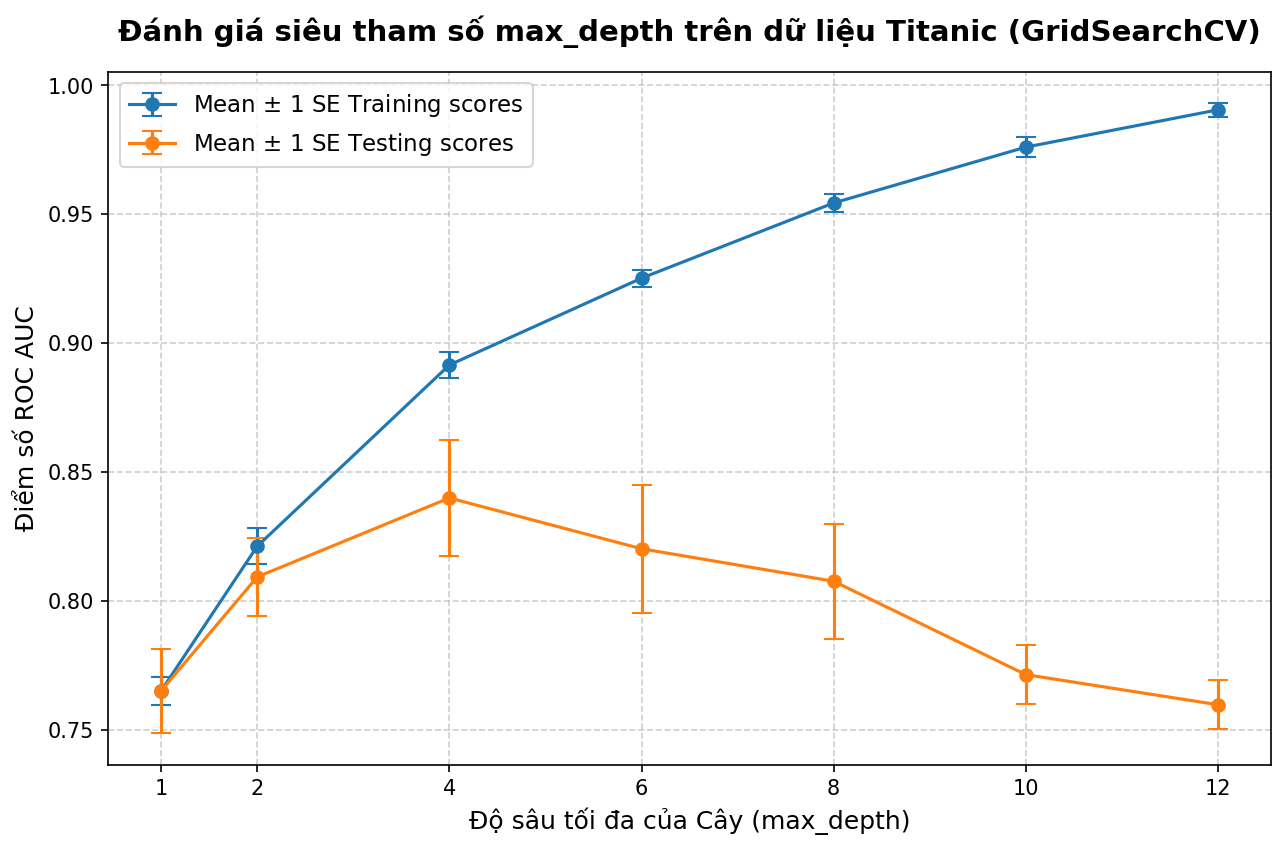

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Chuyển kết quả từ quá trình GridSearchCV (biến cv ở bước trước) thành DataFrame
cv_results_df = pd.DataFrame(cv.cv_results_)

# 2. Thiết lập kích thước và độ nét cho biểu đồ
plt.figure(figsize=(10, 6), dpi=150)
ax = plt.axes()

# 3. Vẽ đường biểu diễn điểm số trên tập Huấn luyện (Training) kèm thanh sai số (Error bar)
ax.errorbar(
    cv_results_df['param_max_depth'].astype(int), # Chuyển đổi kiểu dữ liệu sang int để hiển thị trục X đẹp hơn
    cv_results_df['mean_train_score'], 
    yerr=cv_results_df['std_train_score'] / np.sqrt(4), 
    fmt='-o', # Thêm dấu chấm tròn tại các điểm dữ liệu
    capsize=5, # Thêm thanh chặn ở hai đầu thanh sai số
    label='Mean $\pm$ 1 SE Training scores'
)

# 4. Vẽ đường biểu diễn điểm số trên tập Kiểm tra (Testing) kèm thanh sai số (Error bar)
ax.errorbar(
    cv_results_df['param_max_depth'].astype(int), 
    cv_results_df['mean_test_score'], 
    yerr=cv_results_df['std_test_score'] / np.sqrt(4), 
    fmt='-o', 
    capsize=5,
    label='Mean $\pm$ 1 SE Testing scores'
)

# 5. Cấu hình các chi tiết hiển thị cho biểu đồ Titanic
ax.legend(fontsize=11)
plt.title('Đánh giá siêu tham số max_depth trên dữ liệu Titanic (GridSearchCV)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Độ sâu tối đa của Cây (max_depth)', fontsize=12)
plt.ylabel('Điểm số ROC AUC', fontsize=12)

# Bật lưới tọa độ giúp dễ quan sát điểm cao nhất
plt.grid(True, linestyle='--', alpha=0.6)

# Đảm bảo trục X chỉ hiển thị các số nguyên tương ứng với các giá trị cấu hình max_depth
plt.xticks(params['max_depth'])

# Hiển thị biểu đồ
plt.show()

Hiện tượng Overfitting lộ rõ:Khi max_depth tăng từ 1 lên 12, đường màu xanh (Training score) tăng liên tục và đạt sát mức $1.0$. Mô hình càng ngày càng học vẹt tập train rất tốt.Tuy nhiên, đường màu cam (Testing score) chỉ tăng và đạt đỉnh cao nhất tại điểm max_depth = 4 (với điểm ROC AUC đạt khoảng $0.84$). Ngay sau điểm 4, đường Testing bắt đầu cắm đầu đi xuống liên tục.Kết luận: Lựa chọn max_depth = 4 của thuật toán GridSearchCV là hoàn toàn chính xác. Nó là điểm cân bằng hoàn hảo giúp mô hình đạt độ chính xác cao nhất trên dữ liệu thực tế và tránh được hiện tượng quá khớp.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# 1. Khởi tạo mô hình Random Forest cơ bản (Sửa lại cú pháp sạch sẽ, không dùng gạch chéo \)
rf = RandomForestClassifier(
    n_estimators=10, 
    criterion='gini', 
    max_depth=3, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    max_features='sqrt', 
    bootstrap=True, 
    n_jobs=-1,            # Sử dụng tối đa CPU để chạy nhanh hơn
    random_state=4
)

# 2. Huấn luyện thử nghiệm mô hình rừng cơ bản với dữ liệu Titanic
rf.fit(X_train, y_train)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
print(f"Điểm ROC AUC của Rừng cây cơ bản (10 cây, depth=3): {roc_auc_score(y_test, y_pred_proba_rf):.4f}")


# --- PHẦN VIẾT TIẾP: TỐI ƯU HÓA RỪNG CÂY BẰNG GRIDSEARCHCV ---
print("\n--- Đang tiến hành tối ưu hóa Rừng cây bằng GridSearchCV... ---")

# Thiết lập lưới tham số cho Rừng cây (Thử nghiệm số lượng cây và độ sâu khác nhau)
rf_params = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [3, 5, 8, 10]
}

# Khởi tạo GridSearchCV cho Random Forest
cv_rf = GridSearchCV(
    estimator=RandomForestClassifier(criterion='gini', max_features='sqrt', bootstrap=True, random_state=4),
    param_grid=rf_params,
    scoring='roc_auc',
    cv=4,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Tiến hành tìm kiếm cấu hình Rừng tối ưu nhất trên dữ liệu Titanic
cv_rf.fit(X_train, y_train)

# Xuất cấu hình rừng cây tốt nhất
print(f"\n CẤU HÌNH RỪNG CÂY TỐT NHẤT CHO TITANIC:")
print(f" - Số lượng cây (n_estimators): {cv_rf.best_params_['n_estimators']}")
print(f" - Độ sâu tối đa (max_depth): {cv_rf.best_params_['max_depth']}")

# Đánh giá độ chính xác của Rừng tối ưu trên tập dữ liệu Test chưa từng biết đến
best_rf = cv_rf.best_estimator_
y_test_pred_proba = best_rf.predict_proba(X_test)[:, 1]
final_score = roc_auc_score(y_test, y_test_pred_proba)
print(f" KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG (ROC AUC trên tập Test): {final_score:.4f}")

Điểm ROC AUC của Rừng cây cơ bản (10 cây, depth=3): 0.8606

--- Đang tiến hành tối ưu hóa Rừng cây bằng GridSearchCV... ---
Fitting 4 folds for each of 16 candidates, totalling 64 fits

 CẤU HÌNH RỪNG CÂY TỐT NHẤT CHO TITANIC:
 - Số lượng cây (n_estimators): 100
 - Độ sâu tối đa (max_depth): 8
 KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG (ROC AUC trên tập Test): 0.8779


In [10]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# 1. Định nghĩa lưới tham số quét số lượng cây từ 10 đến 100 (bước nhảy 10)
# list(range(10, 110, 10)) sẽ tạo ra: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
rf_params_ex = {'n_estimators': list(range(10, 110, 10))}

# 2. Cấu hình GridSearchCV (Sửa lại error_score=np.nan chính xác)
cv_rf_ex = GridSearchCV(
    estimator=rf,               # Sử dụng đối tượng mô hình 'rf' đã khởi tạo ở bước trước
    param_grid=rf_params_ex, 
    scoring='roc_auc', 
    n_jobs=-1,                  # Sử dụng tối đa CPU để tăng tốc độ chạy
    refit=True,                 # Tự động train lại mô hình tốt nhất sau khi tìm xong
    cv=4, 
    verbose=1, 
    error_score=np.nan,         # Sửa từ dạng chuỗi 'np.nan' sang biến số thực tế
    return_train_score=True
)

# 3. Thực hiện quét và tìm kiếm trên dữ liệu Titanic
# Tổng cộng: 10 (mức cây) x 4 (lần kiểm định chéo) = 40 lần huấn luyện
cv_rf_ex.fit(X_train, y_train)


# --- PHẦN VIẾT TIẾP: XUẤT THAM SỐ TỐI ƯU VÀ ĐÁNH GIÁ MÔ HÌNH ---

# In ra số lượng cây tối ưu nhất tìm được cho Titanic
best_n_estimators = cv_rf_ex.best_params_['n_estimators']
print(f"\n Số lượng cây (n_estimators) tối ưu nhất cho Titanic: {best_n_estimators} cây")
print(f" Điểm ROC AUC tốt nhất trên tập kiểm định chéo (CV): {cv_rf_ex.best_score_:.4f}")

# Lấy ra mô hình tốt nhất đã được tự động train lại (refit) bằng tham số tối ưu
best_rf_model = cv_rf_ex.best_estimator_

# Dự đoán thử trên tập dữ liệu Test chưa từng được học để kiểm tra độ chính xác thực tế
y_test_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]
final_auc_score = roc_auc_score(y_test, y_test_pred_proba)

print(f" KẾT QUẢ CUỐI CÙNG: Điểm ROC AUC thực tế trên tập Test: {final_auc_score:.4f}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits

 Số lượng cây (n_estimators) tối ưu nhất cho Titanic: 90 cây
 Điểm ROC AUC tốt nhất trên tập kiểm định chéo (CV): 0.8600
 KẾT QUẢ CUỐI CÙNG: Điểm ROC AUC thực tế trên tập Test: 0.8821


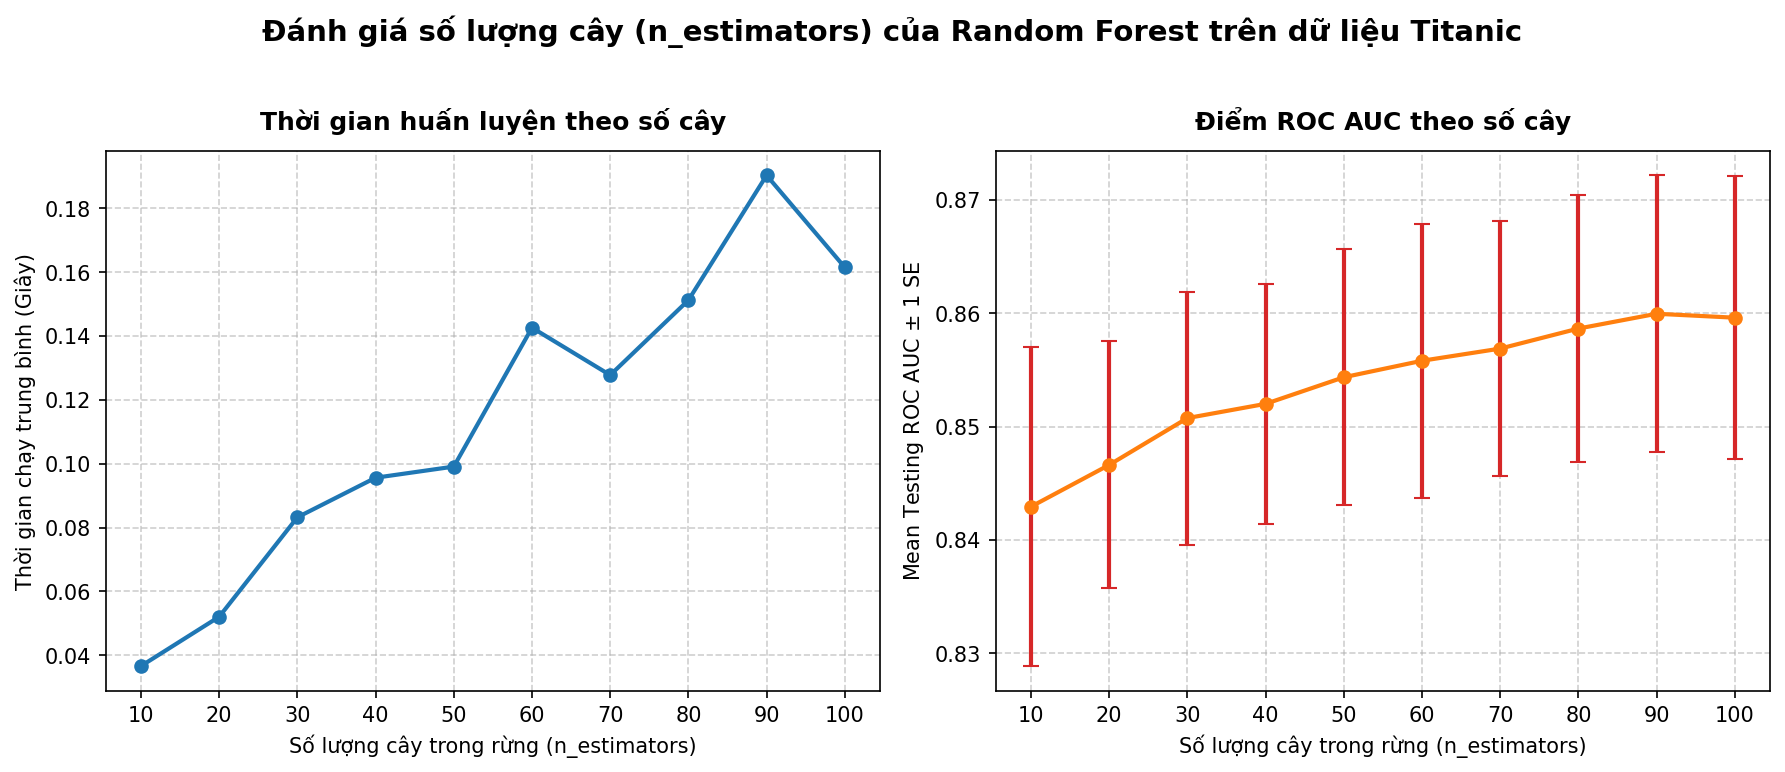

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Chuyển kết quả từ GridSearchCV của Rừng cây thành DataFrame
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

# 2. Khởi tạo khung tranh gồm 1 hàng và 2 cột (Tăng figsize lên 12x5 để hiển thị rộng rãi, nét hơn)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), dpi=150)

# --- BIỂU ĐỒ 1 (Bên trái): Số lượng cây vs Thời gian huấn luyện ---
axs[0].plot(
    cv_rf_ex_results_df['param_n_estimators'].astype(int), 
    cv_rf_ex_results_df['mean_fit_time'], 
    '-o', 
    color='tab:blue', 
    linewidth=2
)
axs[0].set_title('Thời gian huấn luyện theo số cây', fontsize=12, fontweight='bold', pad=10)
axs[0].set_xlabel('Số lượng cây trong rừng (n_estimators)', fontsize=10)
axs[0].set_ylabel('Thời gian chạy trung bình (Giây)', fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].set_xticks(list(range(10, 110, 10))) # Đảm bảo hiện đủ các mốc từ 10 đến 100

# --- BIỂU ĐỒ 2 (Bên phải): Số lượng cây vs Điểm số ROC AUC ---
axs[1].errorbar(
    cv_rf_ex_results_df['param_n_estimators'].astype(int), 
    cv_rf_ex_results_df['mean_test_score'], 
    yerr=cv_rf_ex_results_df['std_test_score'] / np.sqrt(4), 
    fmt='-o', 
    color='tab:orange', 
    ecolor='tab:red', # Màu của thanh sai số
    capsize=4, 
    linewidth=2
)
axs[1].set_title('Điểm ROC AUC theo số cây', fontsize=12, fontweight='bold', pad=10)
axs[1].set_xlabel('Số lượng cây trong rừng (n_estimators)', fontsize=10)
axs[1].set_ylabel('Mean Testing ROC AUC $\pm$ 1 SE', fontsize=10)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].set_xticks(list(range(10, 110, 10)))

# 3. Thêm tiêu đề tổng cho cả bức tranh Titanic
plt.suptitle('Đánh giá số lượng cây (n_estimators) của Random Forest trên dữ liệu Titanic', 
             fontsize=14, fontweight='bold', y=1.02)

# Tự động căn chỉnh khoảng cách giữa các biểu đồ không bị chồng chéo
plt.tight_layout()

# Hiển thị cặp biểu đồ
plt.show()

Thời gian huấn luyện (Biểu đồ trái): Nhìn chung, khi số lượng cây tăng từ 10 lên 100, thời gian chạy có xu hướng tăng dần (đạt đỉnh ở 90 cây). Biến động trồi sụt nhẹ ở các mốc 70 hay 100 cây có thể do cơ chế tối ưu đa luồng CPU (n_jobs=-1) tại thời điểm máy tính xử lý.Hiệu năng ROC AUC (Biểu đồ phải): Điểm số kiểm tra tăng mạnh nhất từ mốc 10 cây đến 30 cây. Từ mốc 40 cây trở đi, đường cong bắt đầu đi ngang và bão hòa quanh mức $0.855$ - $0.860$. Việc tăng lên hẳn 100 cây không làm mô hình mạnh hơn đáng kể mà chỉ làm tốn tài nguyên máy tính.Kết luận: có thể chọn cấu hình khoảng 40 đến 50 cây là điểm tối ưu kinh tế nhất cho mô hình này. Ngoài ra, điểm ROC AUC của Random Forest (~$0.86$) cao hơn hẳn so với Cây quyết định đơn lẻ (~$0.84$), chứng minh sức mạnh vượt trội của việc trồng rừng.

--- THAM SỐ TỐI ƯU NHẤT CỦA RỪNG CÂY ---
{'n_estimators': 90}


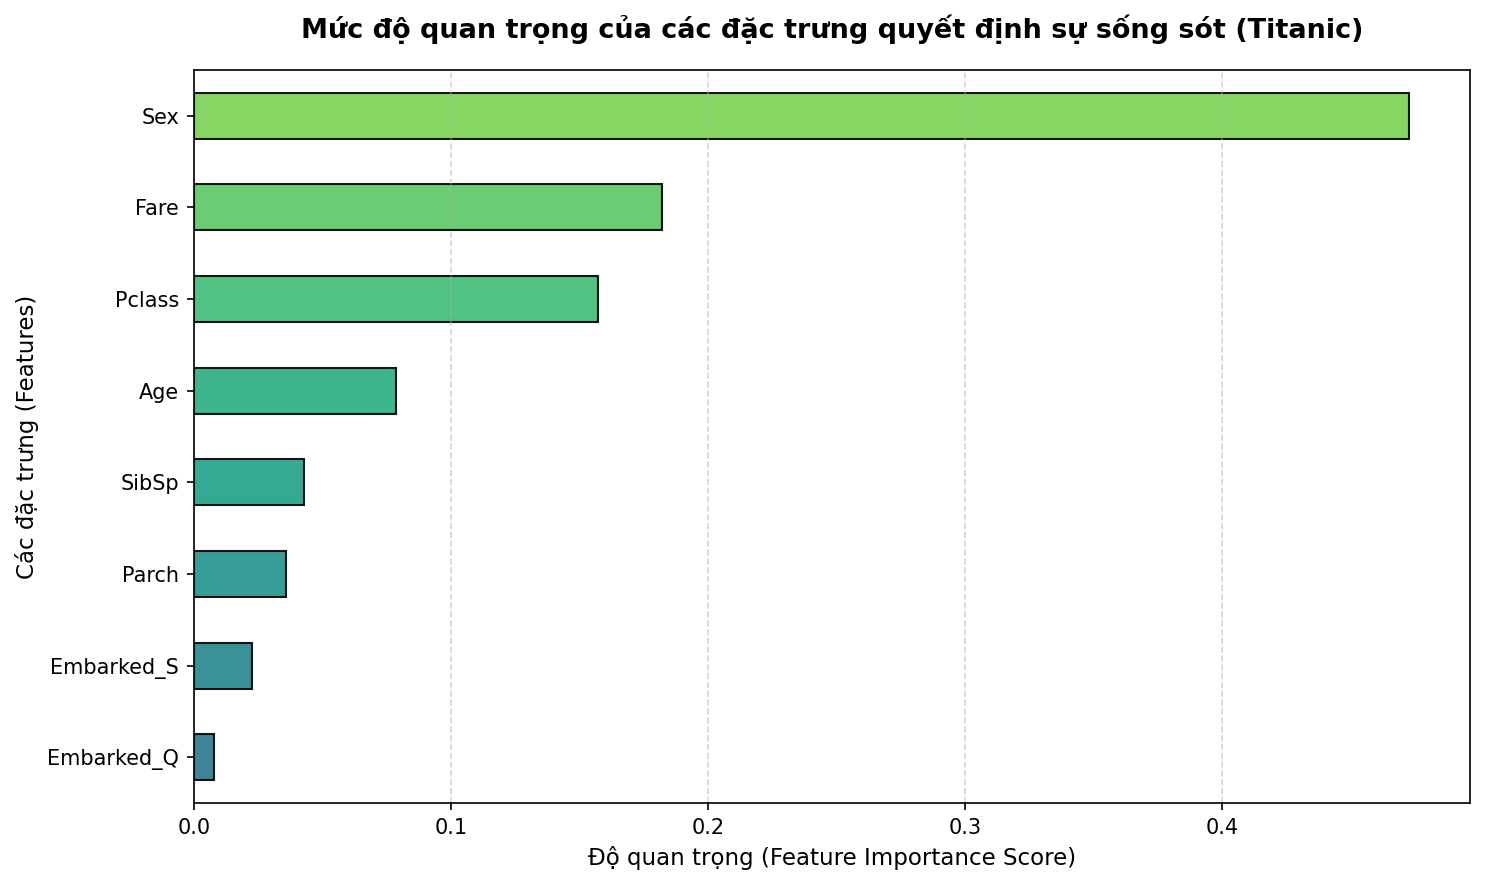

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Hiển thị tham số tối ưu nhất (In ra để kiểm tra)
print("--- THAM SỐ TỐI ƯU NHẤT CỦA RỪNG CÂY ---")
print(cv_rf_ex.best_params_)

# 2. Tạo DataFrame chứa mức độ quan trọng của từng feature
feat_imp_df = pd.DataFrame({
    'Importance': cv_rf_ex.best_estimator_.feature_importances_
}, index=features) # Thay bằng biến 'features' của Titanic

# 3. Sắp xếp lại thứ tự từ quan trọng nhất đến ít quan trọng nhất
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

# 4. Vẽ biểu đồ thanh ngang (Horizontal Bar Plot)
plt.figure(figsize=(10, 6), dpi=150)

# Vẽ các thanh đặc trưng với màu sắc trực quan
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(features)))
feat_imp_df['Importance'].plot.barh(color=colors, edgecolor='black', alpha=0.9)

# Cấu hình các chi tiết hiển thị cho biểu đồ Titanic
plt.title('Mức độ quan trọng của các đặc trưng quyết định sự sống sót (Titanic)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Độ quan trọng (Feature Importance Score)', fontsize=11)
plt.ylabel('Các đặc trưng (Features)', fontsize=11)
plt.grid(True, axis='x', linestyle='--', alpha=0.5) # Chỉ bật lưới dọc để dễ gióng hàng số liệu

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

Sex áp đảo hoàn toàn: Với điểm số tiến gần mức 0.47 (chiếm gần 50% trọng số quyết định của toàn bộ mô hình), Giới tính chính là chiếc "chìa khóa vàng" để dự đoán khả năng sống sót.

Nhóm kinh tế (Fare & Pclass): Đứng ở vị trí thứ 2 và thứ 3 với tổng trọng số khoảng 35%. Điều này chứng minh rằng số tiền bỏ ra mua vé và vị trí cabin đóng vai trò cực kỳ lớn sau giới tính.

Nhóm thông tin cá nhân và hành trình (Age, SibSp, Parch, Embarked): Chiếm tỷ trọng khá nhỏ ở phía dưới. Đáng chú ý là địa điểm lên tàu (Embarked_Q, Embarked_S) hầu như không có tiếng nói trong việc quyết định hành khách đó có sống sót hay không.